# Testing The End of Everything

We have done tests to establish a System Usability Score (SUS), A/B design tests between a version of our apps with heavy use of guardrails and one completely void of such.
We will be using the Game Engagement Questionnaire standardized test for the A/B test.

## System Usability Score

In [1]:
# Import
from scipy import stats
from matplotlib import pyplot as plt
import re
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu

In [2]:
# Load the data
dfSus = pd.read_csv("Data/SUSTest1_v6.csv")

In [3]:
# Clean the data

# Extract only the numeric response (e.g., "4 (Agree)" → 4)
def extract_numeric(response):
    match = re.match(r"(\d)", str(response))
    return int(match.group(1)) if match else None

# Columns corresponding to each SUS statement
sus_columns = [
    "STATEMENT 1: “I think that I would like to use this system frequently.”",
    "STATEMENT 2: “I found the system unnecessarily complex.”",
    "STATEMENT 3: “I thought the system was easy to use.”",
    "STATEMENT 4: “I think that I would need the support of a technical person to use this system.”",
    "STATEMENT 5: “I found the various functions in this system were well integrated.”",
    "STATEMENT 6: “I thought there was too much inconsistency in this system.”",
    "STATEMENT 7: “I would imagine that most people would learn to use this system very quickly.”",
    "STATEMENT 8: “I found the system very cumbersome to use.”",
    "STATEMENT 9: “I felt very confident using the system.”",
    "STATEMENT 10: ”I needed to learn a lot of things before I could get going with this system.”"
]

# Apply extraction to the SUS columns
sus_numeric = dfSus[sus_columns].map(extract_numeric)

In [4]:
# Compute adjusted scores
adjusted_scores = sus_numeric.copy()
for i in range(10):
    if (i + 1) % 2 == 1:  # Odd-numbered (positive) questions
        adjusted_scores.iloc[:, i] = sus_numeric.iloc[:, i] - 1
    else:  # Even-numbered (negative) questions
        adjusted_scores.iloc[:, i] = 5 - sus_numeric.iloc[:, i]

# Sum and compute final SUS score
dfSus["SUS Score"] = adjusted_scores.sum(axis=1) * 2.5

In [5]:
# Print the results
print(dfSus[["SUS Score"]])
dfSus["SUS Score"].describe()

    SUS Score
0        75.0
1        92.5
2        72.5
3        92.5
4        70.0
5        72.5
6        75.0
7        75.0
8        85.0
9        75.0
10       77.5
11       75.0
12       72.5
13       82.5


count    14.000000
mean     78.035714
std       7.283977
min      70.000000
25%      73.125000
50%      75.000000
75%      81.250000
max      92.500000
Name: SUS Score, dtype: float64

((array([-1.66151682, -1.18948235, -0.88997893, -0.65463235, -0.45108016,
         -0.2648058 , -0.08735875,  0.08735875,  0.2648058 ,  0.45108016,
          0.65463235,  0.88997893,  1.18948235,  1.66151682]),
  array([70. , 72.5, 72.5, 72.5, 75. , 75. , 75. , 75. , 75. , 77.5, 82.5,
         85. , 92.5, 92.5])),
 (np.float64(7.043135052086344),
  np.float64(78.03571428571429),
  np.float64(0.9036769585322585)))

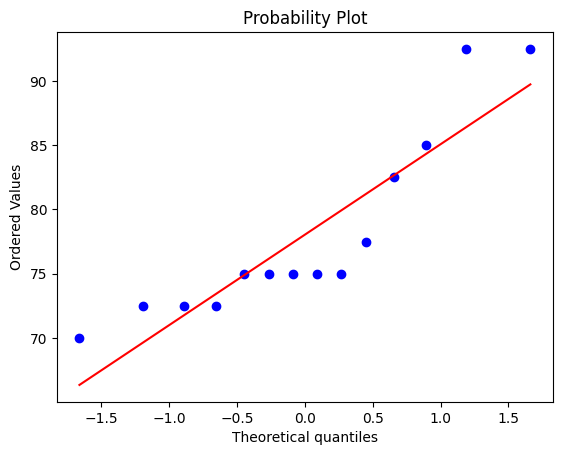

In [6]:
# Plot the results
stats.probplot(dfSus["SUS Score"], plot=plt)

In [7]:
stat, p, = stats.shapiro(dfSus["SUS Score"])
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.810, p=0.007


(array([1., 3., 0., 5., 1., 0., 0., 1., 0., 1., 0., 0., 0., 2.]),
 array([70.        , 71.60714286, 73.21428571, 74.82142857, 76.42857143,
        78.03571429, 79.64285714, 81.25      , 82.85714286, 84.46428571,
        86.07142857, 87.67857143, 89.28571429, 90.89285714, 92.5       ]),
 <BarContainer object of 14 artists>)

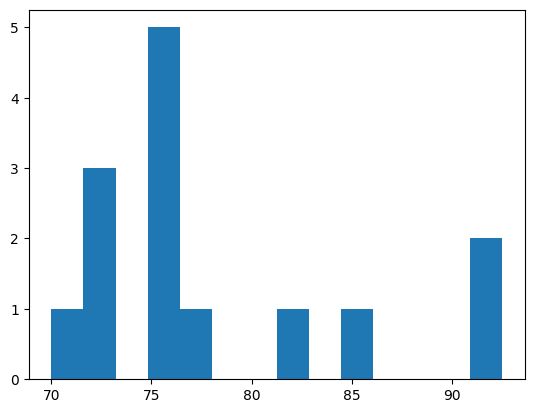

In [8]:
plt.hist(dfSus["SUS Score"], bins=14)

we reject the null hypothesis that the data is normally distributed. The following t-test will not be valid.

In [9]:
# CI
mean = dfSus["SUS Score"].mean()
sem = stats.sem(dfSus["SUS Score"])
ci = stats.t.interval(0.95, len(dfSus["SUS Score"]) - 1, loc=mean, scale=sem)
print(f"95% CI: {ci}")

95% CI: (np.float64(73.83007126602777), np.float64(82.24135730540081))


In [10]:
# Perform a one-sample t-test
t_stat, p_value = stats.ttest_1samp(dfSus["SUS Score"], popmean=67)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 5.6688623197251875
p-value: 7.682928876878458e-05


In [11]:
stat, p = wilcoxon(dfSus["SUS Score"] - 67)

print(f"Wilcoxon statistic: {stat}, p-value: {p}")

Wilcoxon statistic: 0.0, p-value: 0.0001220703125


Adjusted Wald CI for proportion above 67: (0.744, 1.034)


In [13]:
dfSus["Above_67"] = (dfSus["SUS Score"] > 67).astype(int)

# Step 2: Calculate the proportion of scores above 67
x = dfSus["Above_67"].sum()  # Total number of successes (1's)
n = len(dfSus)  # Total number of samples

crit=1.96

# We can thus calculate n_adjusted as
n_adj= n+(crit ** 2)

# and p_adjusted as
p_adj= (x+((crit  ** 2)/2))/(n_adj)
p_adj

print(n)

14


In [14]:
# and then find the upper and lower confidence intervals by entering these

Wald_upper=p_adj + crit * np.sqrt((p_adj*(1-p_adj))/n_adj)
print('95% upper confidence limit:', (Wald_upper))

Wald_lower=p_adj - crit * np.sqrt((p_adj*(1-p_adj))/n_adj)
print('95% lower confidence limit:', (Wald_lower))

95% upper confidence limit: 1.0361646752080802
95% lower confidence limit: 0.7485183128647385


The true proportion of people who score above 67 is likely to fall somewhere between 74.4% and 103.4%, but since a proportion can’t exceed 100% (1.0), we interpret the upper bound as 100%.

## Game Engagement Questionnaire

In [15]:
# Load the data
dfAb = pd.read_csv("Data/ABTest_v1.csv")

# Check the data
dfAb

,Name,ID,Respondent,Submission time,Test,Daily phone,Ending,Playtime in minutes,A01 I lose track of time,A02 Things seem to happen automatically,...,B01 I could easily follow the sequence of events in the game's story.,B02 The sequence of events in the game made logical sense to me.,B03 The game's objectives were clear to me throughout the gameplay.,B04 I felt like my actions affected the outcome of the game.,B05 I understood the motivation/meaning behind the main contacts messages.,B06 I had no unanswered questions about the story after completing the game,B07 I felt that the story reached a complete ending.,B08 All major plot points were resolved by the end of the game.,B09 I was left with a clear understanding of the story's outcome.,B10 The ending of the game felt appropriate for the story told.
0,1,P2N-4,Anonymous,"May 7, 2025 11:31 AM",Linear,1 iPhone,2 Reset,16,3 Yes,3 Yes,...,5,6,5,7,4,2,3,3,3,5
1,2,P2N-5,Anonymous,"May 7, 2025 12:03 PM",Linear,1 iPhone,3 Backup,15,2 Maybe,3 Yes,...,5,5,5,4,4,1,4,3,3,5
2,3,P2N-6,Anonymous,"May 7, 2025 12:54 PM",Linear,2 Android,3 Backup,19,3 Yes,2 Maybe,...,5,4,4,6,3,3,3,4,4,6
3,4,P2N-7,Anonymous,"May 7, 2025 1:16 PM",Linear,2 Android,2 Reset,8,2 Maybe,1 No,...,5,5,3,3,5,1,2,3,2,3
4,5,P2N-8,Anonymous,"May 7, 2025 1:42 PM",Linear,2 Android,2 Reset,12,3 Yes,3 Yes,...,5,5,6,4,3,3,4,2,3,3
5,6,P2N-9,Anonymous,"May 7, 2025 2:04 PM",Linear,2 Android,2 Reset,10,2 Maybe,3 Yes,...,3,3,3,4,3,1,1,1,1,1
6,7,P2N-10,Anonymous,"May 9, 2025 12:18 PM",Open,2 Android,3 Backup,9,1 No,1 No,...,5,5,5,5,3,3,4,3,3,3
7,8,P2N-11,Anonymous,"May 9, 2025 12:35 PM",Open,1 iPhone,1 Aborted,3,3 Yes,1 No,...,3,5,5,3,4,3,4,2,5,2
8,9,P2N-12,Anonymous,"May 9, 2025 12:50 PM",Open,2 Android,1 Aborted,4,2 Maybe,3 Yes,...,4,4,2,2,2,3,4,4,2,3
9,10,P2N-13,Anonymous,"May 9, 2025 1:10 PM",Open,1 iPhone,3 Backup,10,3 Yes,1 No,...,6,7,4,5,6,2,6,5,5,7


,B01 I could easily follow the sequence of events in the game's story.
6,5
7,3
8,4
9,6
10,5
11,3


In [17]:

# Filter for columns that start with 'A' and contain a number (A01–A19)
a_columns = [col for col in dfAb.columns if col.startswith("A") and col[1:3].isdigit() and int(col[1:3]) in range(1, 20)]

# Include 'Test' column for filtering
a_df = dfAb[["Test"] + a_columns]

# Split into two DataFrames based on the Test column
open_df = a_df[a_df["Test"] == "Open"].reset_index(drop=True)
linear_df = a_df[a_df["Test"] == "Linear"].reset_index(drop=True)

# Optional: drop the 'Test' column if you don't need it anymore
open_df = open_df.drop(columns=["Test"])
linear_df = linear_df.drop(columns=["Test"])

open_df = open_df.map(extract_numeric)
linear_df = linear_df.map(extract_numeric)

# Now you can describe the cleaned numeric responses
print(open_df.describe())
print(linear_df.describe())

       A01 I lose track of time  A02 Things seem to happen automatically  \
count                   6.00000                                 6.000000   
mean                    2.50000                                 1.333333   
std                     0.83666                                 0.816497   
min                     1.00000                                 1.000000   
25%                     2.25000                                 1.000000   
50%                     3.00000                                 1.000000   
75%                     3.00000                                 1.000000   
max                     3.00000                                 3.000000   

       A03 I feel different  A04 I feel scared  A05 The game feels real  \
count              6.000000           6.000000                 6.000000   
mean               2.166667           1.666667                 2.333333   
std                0.752773           0.816497                 0.816497   
min            

In [18]:
open_totals = open_df.sum(axis=1)
linear_totals = linear_df.sum(axis=1)

print(open_totals.describe())
print(linear_totals.describe())

count     6.000000
mean     40.000000
std       4.242641
min      34.000000
25%      37.000000
50%      41.000000
75%      42.750000
max      45.000000
dtype: float64
count     6.000000
mean     36.833333
std       4.956477
min      32.000000
25%      33.500000
50%      35.000000
75%      40.250000
max      44.000000
dtype: float64


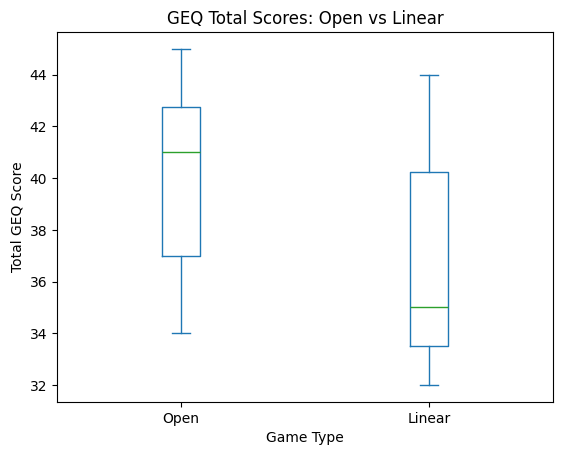

In [19]:
comparison_df = pd.DataFrame({"Open": open_totals,"Linear": linear_totals})

# Make boxplot
comparison_df.plot.box()

# Add labels
plt.title("GEQ Total Scores: Open vs Linear")
plt.ylabel("Total GEQ Score")
plt.xlabel("Game Type")

# Show the plot
plt.show()

linear scores lower than open scores, but we need to check if this is statistically significant.

(array([[0., 1., 1., 0., 1., 0., 2., 1.],
        [2., 2., 0., 0., 0., 0., 1., 1.]]),
 array([32.   , 33.625, 35.25 , 36.875, 38.5  , 40.125, 41.75 , 43.375,
        45.   ]),
 <a list of 2 BarContainer objects>)

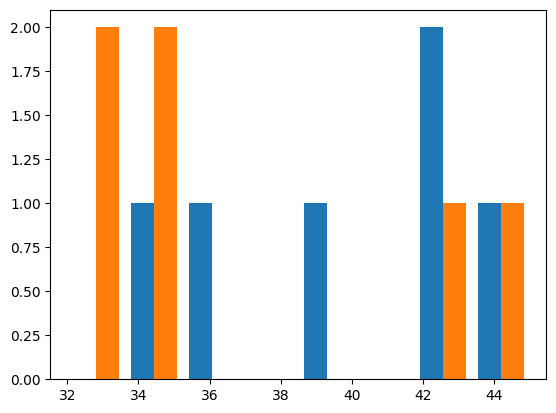

In [20]:
plt.hist(comparison_df, bins=8)

Plot the histogram of the two distributions

In [21]:
mean = linear_totals.mean()
sem = stats.sem(linear_totals)
ci = stats.t.interval(0.95, len(linear_totals) - 1, loc=mean, scale=sem)
print(f"linear 95% CI: {ci}")

linear 95% CI: (np.float64(31.63182946552988), np.float64(42.034837201136796))


In [22]:
mean = open_totals.mean()
sem = stats.sem(open_totals)
ci = stats.t.interval(0.95, len(open_totals) - 1, loc=mean, scale=sem)
print(f"open 95% CI: {ci}")

open 95% CI: (np.float64(35.54762165566424), np.float64(44.45237834433576))


CI's overlap, but we need to check if the difference is statistically significant.

((array([-1.23132171, -0.63003387, -0.19819716,  0.19819716,  0.63003387,
          1.23132171]),
  array([34, 36, 40, 42, 43, 45])),
 (np.float64(4.6996971659875895),
  np.float64(40.0),
  np.float64(0.9789163098150727)))

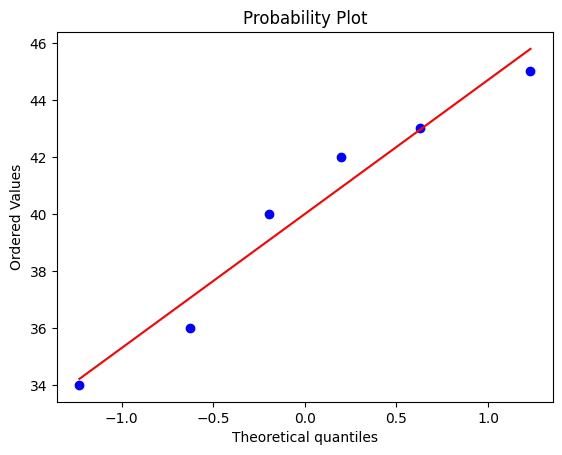

In [23]:
stats.probplot(open_totals, plot=plt)

In [24]:
stat, p, = stats.shapiro(open_totals)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.943, p=0.686


((array([-1.23132171, -0.63003387, -0.19819716,  0.19819716,  0.63003387,
          1.23132171]),
  array([32, 33, 35, 35, 42, 44])),
 (np.float64(5.236221132782166),
  np.float64(36.833333333333336),
  np.float64(0.9335913200313177)))

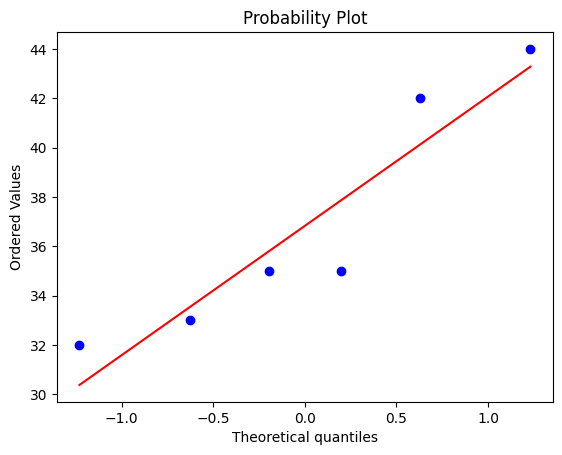

In [25]:
stats.probplot(linear_totals, plot=plt)

In [26]:
stat, p, = stats.shapiro(linear_totals)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.854, p=0.170


In [27]:
stat, p = stats.levene(linear_totals, open_totals)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.008431703204047203, p-value: 0.9286510664153064


they both have a normal distribution, and the variances are equal.

In [28]:
t_stat, p_value = stats.ttest_ind(open_totals, linear_totals)


print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 1.188894052524624, P-value: 0.2619467224252576


we cannot discard our null hypothosis , that there is no difference between the two tests. since the p-value is greater than 0.05.

In [44]:
open_dfB = dfAb[dfAb['Test'] == 'Open']
linear_dfB = dfAb[dfAb['Test'] == 'Linear']
# Extracting the values as 1D arrays for each statement
open_dfB01 = open_dfB["B01 I could easily follow the sequence of events in the game's story."].values
linear_dfB01 = linear_dfB["B01 I could easily follow the sequence of events in the game's story."].values

open_dfB02 = open_dfB["B02 The sequence of events in the game made logical sense to me."].values
linear_dfB02 = linear_dfB["B02 The sequence of events in the game made logical sense to me."].values

open_dfB03 = open_dfB["B03 The game's objectives were clear to me throughout the gameplay."].values
linear_dfB03 = linear_dfB["B03 The game's objectives were clear to me throughout the gameplay."].values

open_dfB04 = open_dfB["B04 I felt like my actions affected the outcome of the game."].values
linear_dfB04 = linear_dfB["B04 I felt like my actions affected the outcome of the game."].values

open_dfB05 = open_dfB["B05 I understood the motivation/meaning behind the main contacts messages."].values
linear_dfB05 = linear_dfB["B05 I understood the motivation/meaning behind the main contacts messages."].values

open_dfB06 = open_dfB["B06 I  had no  unanswered questions about the story after completing the game"].values
linear_dfB06 = linear_dfB["B06 I  had no  unanswered questions about the story after completing the game"].values

open_dfB07 = open_dfB["B07 I felt that the story reached a complete ending."].values
linear_dfB07 = linear_dfB["B07 I felt that the story reached a complete ending."].values

open_dfB08 = open_dfB["B08 All major plot points were resolved by the end of the game."].values
linear_dfB08 = linear_dfB["B08 All major plot points were resolved by the end of the game."].values

open_dfB09 = open_dfB["B09 I was left with a clear understanding of the story's outcome."].values
linear_dfB09 = linear_dfB["B09 I was left with a clear understanding of the story's outcome."].values

open_dfB10 = open_dfB["B10 The ending of the game felt appropriate for the story told."].values
linear_dfB10 = linear_dfB["B10 The ending of the game felt appropriate for the story told."].values


In [63]:
open_dfB["B01 I could easily follow the sequence of events in the game's story."].describe()


count    6.000000
mean     4.333333
std      1.211060
min      3.000000
25%      3.250000
50%      4.500000
75%      5.000000
max      6.000000
Name: B01 I could easily follow the sequence of events in the game's story., dtype: float64

B01 question


In [52]:
stat, p, = stats.shapiro(open_dfB01)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.907, p=0.415


In [48]:
stat, p, = stats.shapiro(linear_dfB01)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.496, p=0.000


In [49]:
stat, p = stats.levene(open_dfB01,linear_dfB01)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 2.7586206896551726, p-value: 0.12771572871830003


linear data is not normally distributed, but open data is. We will use the Mann-Whitney U test to compare the two groups.

In [53]:
stat, p_value = mannwhitneyu(open_dfB01, linear_dfB01)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=15.00, p=0.65


In [54]:
#just for fun, check the independent t test
t_stat, p_value = stats.ttest_ind(open_dfB01, linear_dfB01)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -0.5590169943749485, P-value: 0.5884493383159473


<Axes: >

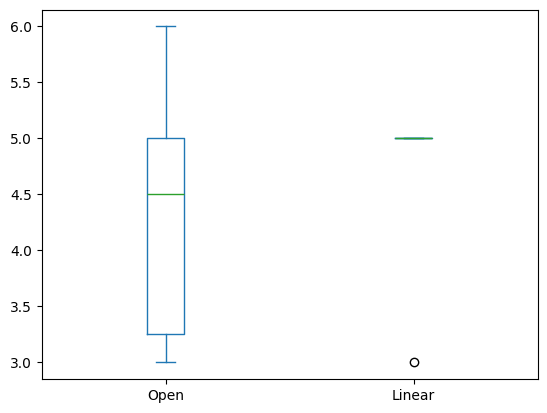

In [55]:
comparison_dfB01 = pd.DataFrame({"Open": open_dfB01,"Linear": linear_dfB01})

comparison_dfB01.plot.box()

There is no significant difference between the two groups, since the p-value is greater than 0.05.

In [56]:
open_mean = np.mean(open_dfB01)
open_std = np.std(open_dfB01)
open_n = len(open_dfB01)

linear_mean = np.mean(linear_dfB01)
linear_std = np.std(linear_dfB01)
linear_n = len(linear_dfB01)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 4.333333333333333, CI: (np.float64(3.173138580279499), np.float64(5.493528086387167))
Linear Mean: 4.666666666666667, CI: (np.float64(3.884463523727197), np.float64(5.448869809606137))


B02 question

stat, p, = stats.shapiro(open_dfB02)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

In [57]:
stat, p, = stats.shapiro(open_dfB02)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.927, p=0.554


In [58]:
stat, p, = stats.shapiro(linear_dfB02)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.915, p=0.473


In [59]:
stat, p = stats.levene(open_dfB02,linear_dfB02)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.4878048780487806, p-value: 0.5008270842295446


since both are normally distributed and have equal variance, we can use the t-test to compare the two groups.

In [60]:
# perform mann whitney test for fun
stat, p_value = mannwhitneyu(open_dfB02, linear_dfB02)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=16.50, p=0.87


In [61]:
t_stat, p_value = stats.ttest_ind(open_dfB02, linear_dfB02)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 0.0, P-value: 1.0


No difference at all, there is a 100% chance that the two groups are the same. haha

<Axes: >

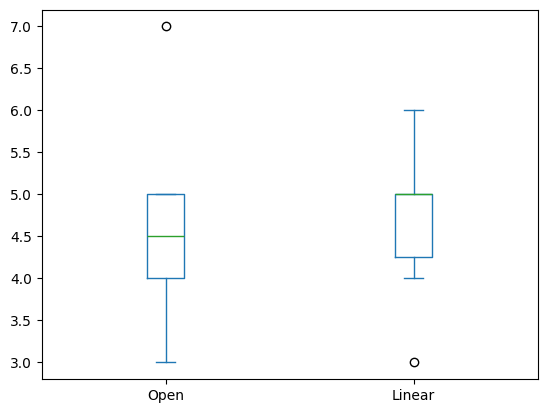

In [64]:
comparison_dfB02 = pd.DataFrame({"Open": open_dfB02,"Linear": linear_dfB02})

comparison_dfB02.plot.box()

In [65]:
open_mean = np.mean(open_dfB02)
open_std = np.std(open_dfB02)
open_n = len(open_dfB02)

linear_mean = np.mean(linear_dfB02)
linear_std = np.std(linear_dfB02)
linear_n = len(linear_dfB02)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 4.666666666666667, CI: (np.float64(3.357790462013118), np.float64(5.975542871320216))
Linear Mean: 4.666666666666667, CI: (np.float64(3.6772492568142745), np.float64(5.656084076519059))


B03 question

In [139]:
stat, p, = stats.shapiro(open_dfB03)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.861, p=0.191


In [142]:
stat, p, = stats.shapiro(linear_dfB03)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.907, p=0.415


In [143]:
stat, p = stats.levene(open_dfB03,linear_dfB03)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.2941176470588237, p-value: 0.5994703106545742


since both are normally distributed and have equal variance, we can use the t-test to compare the two groups.


In [69]:
# perform mann whitney test for fun
stat, p_value = mannwhitneyu(open_dfB03, linear_dfB03)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=11.50, p=0.32


In [70]:
t_stat, p_value = stats.ttest_ind(open_dfB03, linear_dfB03)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -1.1124853987249617, P-value: 0.2919576149178885


There is no significant difference between the two groups, since the p-value is greater than 0.05.


<Axes: >

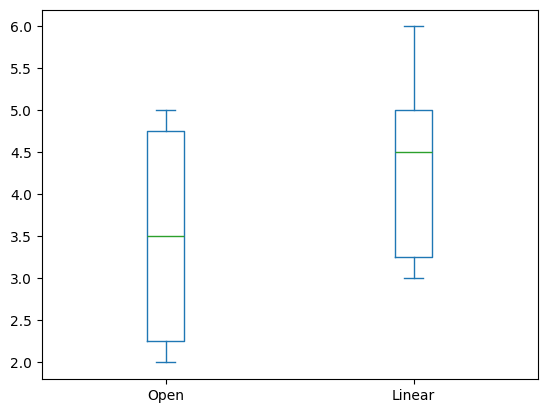

In [71]:
comparison_dfB03 = pd.DataFrame({"Open": open_dfB03,"Linear": linear_dfB03})

comparison_dfB03.plot.box()

In [72]:
open_mean = np.mean(open_dfB03)
open_std = np.std(open_dfB03)
open_n = len(open_dfB03)

linear_mean = np.mean(linear_dfB03)
linear_std = np.std(linear_dfB03)
linear_n = len(linear_dfB03)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 3.5, CI: (np.float64(2.179489111385484), np.float64(4.820510888614516))
Linear Mean: 4.333333333333333, CI: (np.float64(3.173138580279499), np.float64(5.493528086387167))


B04 question

In [73]:
stat, p, = stats.shapiro(open_dfB04)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.831, p=0.110


In [74]:
stat, p, = stats.shapiro(linear_dfB04)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.866, p=0.212


In [75]:
stat, p = stats.levene(open_dfB04,linear_dfB04)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.0, p-value: 1.0


since both are normally distributed and have equal variance, we can use the t-test to compare the two groups.


In [76]:
# for fun
stat, p_value = mannwhitneyu(open_dfB04, linear_dfB04)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))


Statistics=15.00, p=0.68


In [77]:
t_stat, p_value = stats.ttest_ind(linear_dfB04, open_dfB04)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 0.8304547985374001, P-value: 0.42566403851161827


There is no significant difference between the two groups, since the p-value is greater than 0.05.


<Axes: >

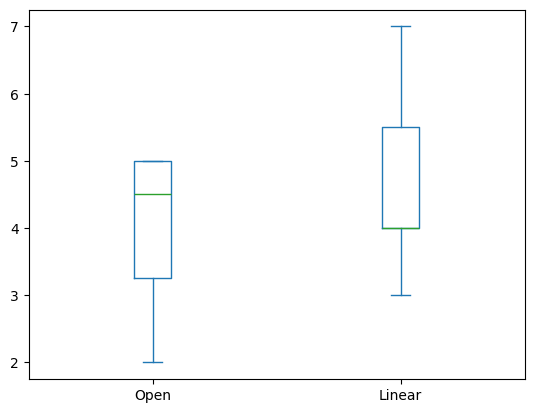

In [78]:
comparison_dfB04 = pd.DataFrame({"Open": open_dfB04,"Linear": linear_dfB04})

comparison_dfB04.plot.box()

In [79]:
open_mean = np.mean(open_dfB04)
open_std = np.std(open_dfB04)
open_n = len(open_dfB04)

linear_mean = np.mean(linear_dfB04)
linear_std = np.std(linear_dfB04)
linear_n = len(linear_dfB04)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 4.0, CI: (np.float64(2.7882161016177327), np.float64(5.211783898382267))
Linear Mean: 4.666666666666667, CI: (np.float64(3.224355336473733), np.float64(6.1089779968596005))


B05 question

In [85]:
stat, p, = stats.shapiro(open_dfB05)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.958, p=0.804


In [84]:
stat, p, = stats.shapiro(linear_dfB05)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.822, p=0.091


In [83]:
stat, p = stats.levene(open_dfB05,linear_dfB05)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 1.8000000000000007, p-value: 0.20938312742864554


since both are normally distributed and not significantly different variance, we can use the t-test to compare the two groups.


In [82]:
# for fun
stat, p_value = mannwhitneyu(open_dfB05, linear_dfB05)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=18.50, p=1.00


In [80]:
t_stat, p_value = stats.ttest_ind(linear_dfB05, open_dfB05)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -0.2425356250363334, P-value: 0.813267092842176


There is no significant difference between the two groups, since the p-value is greater than 0.05.

<Axes: >

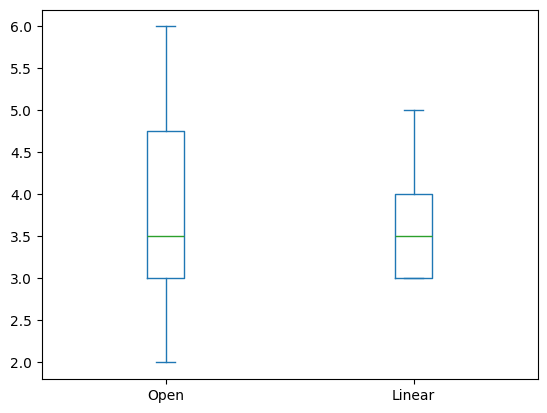

In [81]:
comparison_dfB05 = pd.DataFrame({"Open": open_dfB05,"Linear": linear_dfB05})

comparison_dfB05.plot.box()

In [86]:
open_mean = np.mean(open_dfB05)
open_std = np.std(open_dfB05)
open_n = len(open_dfB05)

linear_mean = np.mean(linear_dfB05)
linear_std = np.std(linear_dfB05)
linear_n = len(linear_dfB05)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 3.8333333333333335, CI: (np.float64(2.4231965634846593), np.float64(5.243470103182007))
Linear Mean: 3.6666666666666665, CI: (np.float64(2.884463523727196), np.float64(4.448869809606137))


B06 question

In [220]:
stat, p, = stats.shapiro(open_dfB06)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.827, p=0.101


In [89]:
stat, p, = stats.shapiro(linear_dfB06)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.775, p=0.035


In [92]:
stat, p = stats.levene(open_dfB06,linear_dfB06)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 2.8125000000000004, p-value: 0.12446408993655922


Since the p-value is less than 0.05 for the shaprio wilk test we reject the null hypothesis that the data is noramlly distributed

In [87]:
stat, p_value = mannwhitneyu(open_dfB06, linear_dfB06)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))


Statistics=29.50, p=0.06


In [90]:
t_stat, p_value = stats.ttest_ind(linear_dfB06, open_dfB06)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -2.4445060351935237, P-value: 0.03458134743591216


Okay so technicly we cant accept this but the t test says there is evedence to reject the null fypothosis that there isnt a difference?

<Axes: >

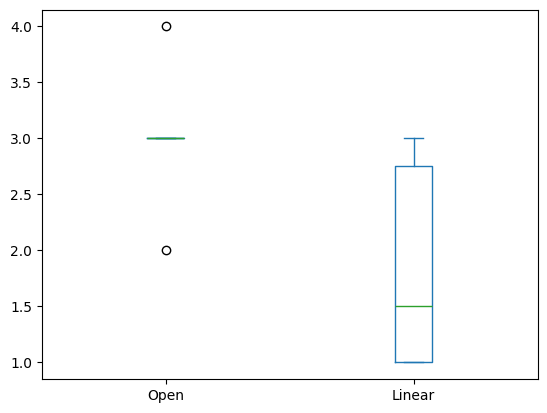

In [93]:
comparison_dfB06 = pd.DataFrame({"Open": open_dfB06,"Linear": linear_dfB06})

comparison_dfB06.plot.box()

In [94]:
open_mean = np.mean(open_dfB06)
open_std = np.std(open_dfB06)
open_n = len(open_dfB06)

linear_mean = np.mean(linear_dfB06)
linear_std = np.std(linear_dfB06)
linear_n = len(linear_dfB06)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 3.0, CI: (np.float64(2.3941080508088666), np.float64(3.6058919491911334))
Linear Mean: 1.8333333333333333, CI: (np.float64(0.891436020779911), np.float64(2.7752306458867553))


The linear scored lower than the open mean... whaat?

B07 question

In [96]:
stat, p, = stats.shapiro(open_dfB07)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.822, p=0.091


In [97]:
stat, p, = stats.shapiro(linear_dfB07)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.908, p=0.421


In [98]:
stat, p = stats.levene(open_dfB07,linear_dfB07)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.22727272727272751, p-value: 0.6437997673753593


We can use t-test since the data is normally distributed and has equal variance.

In [99]:
stat, p_value = mannwhitneyu(open_dfB07, linear_dfB07)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=33.00, p=0.02


In [100]:
t_stat, p_value = stats.ttest_ind(linear_dfB07, open_dfB07)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -3.1492908387262757, P-value: 0.01034542658091523


We can reject the null hypotosis!!!

<Axes: >

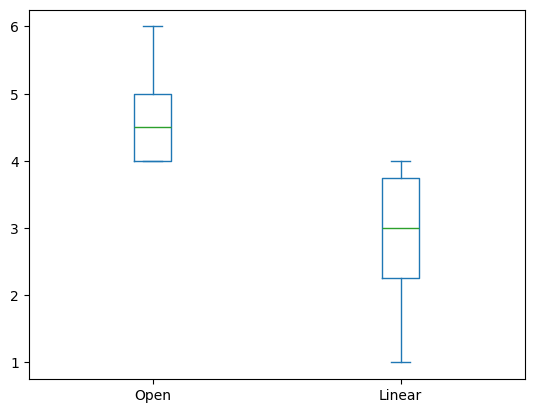

In [101]:
comparison_dfB07 = pd.DataFrame({"Open": open_dfB07,"Linear": linear_dfB07})

comparison_dfB07.plot.box()

In [102]:
open_mean = np.mean(open_dfB07)
open_std = np.std(open_dfB07)
open_n = len(open_dfB07)

linear_mean = np.mean(linear_dfB07)
linear_std = np.std(linear_dfB07)
linear_n = len(linear_dfB07)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 4.666666666666667, CI: (np.float64(3.884463523727197), np.float64(5.448869809606137))
Linear Mean: 2.8333333333333335, CI: (np.float64(1.713388869759362), np.float64(3.953277796907305))


but what the hell the open group is higher than the linear group, this is not what we expected.

B08 question

In [103]:
stat, p, = stats.shapiro(open_dfB08)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.908, p=0.421


In [105]:
stat, p, = stats.shapiro(linear_dfB08)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.915, p=0.473


In [106]:
stat, p = stats.levene(open_dfB08,linear_dfB08)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.13513513513513525, p-value: 0.7208269913626657


We can use t-test since the data is normally distributed and has equal variance.

In [121]:
stat, p_value = mannwhitneyu(open_dfB08, linear_dfB08)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=28.00, p=0.12


In [122]:
t_stat, p_value = stats.ttest_ind(linear_dfB08, open_dfB08)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -1.8319837290657486, P-value: 0.09686101517571298


Close but no cigar, we can reject the null hypothesis that there is no difference between the two groups.

<Axes: >

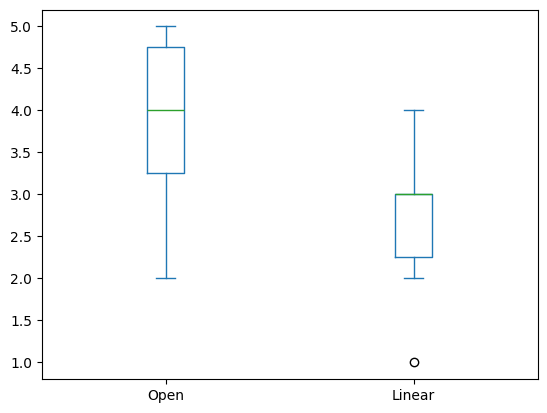

In [114]:
comparison_dfB08 = pd.DataFrame({"Open": open_dfB08,"Linear": linear_dfB08})

comparison_dfB08.plot.box()

In [115]:
open_mean = np.mean(open_dfB08)
open_std = np.std(open_dfB08)
open_n = len(open_dfB08)

linear_mean = np.mean(linear_dfB08)
linear_std = np.std(linear_dfB08)
linear_n = len(linear_dfB08)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 3.8333333333333335, CI: (np.float64(2.713388869759362), np.float64(4.9532777969073045))
Linear Mean: 2.6666666666666665, CI: (np.float64(1.6772492568142743), np.float64(3.6560840765190585))


B09 question

In [116]:
stat, p, = stats.shapiro(open_dfB09)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.908, p=0.421


In [117]:
stat, p, = stats.shapiro(linear_dfB09)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.915, p=0.473


In [124]:
stat, p = stats.levene(open_dfB09,linear_dfB09)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.13513513513513525, p-value: 0.7208269913626657


All data is normally distributed and has equal variance, we can use the t-test to compare the two groups.

In [123]:
stat, p_value = mannwhitneyu(open_dfB09, linear_dfB09)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=28.00, p=0.12


In [125]:
t_stat, p_value = stats.ttest_ind(linear_dfB09, open_dfB09)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -1.8319837290657486, P-value: 0.09686101517571298


Close but not quite, we can't reject the null hypothesis that there is no difference between the two groups.

<Axes: >

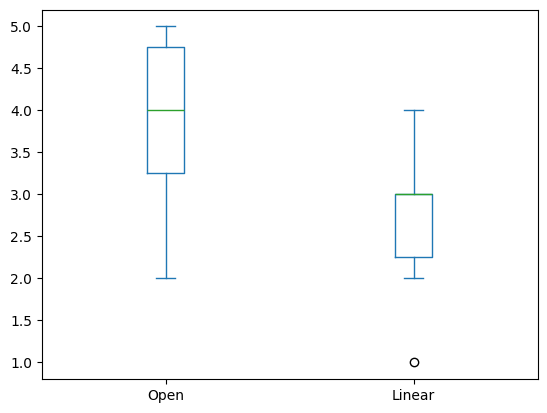

In [136]:
comparison_dfB09 = pd.DataFrame({"Open": open_dfB09,"Linear": linear_dfB09})

comparison_dfB09.plot.box()

In [127]:
open_mean = np.mean(open_dfB09)
open_std = np.std(open_dfB09)
open_n = len(open_dfB09)

linear_mean = np.mean(linear_dfB09)
linear_std = np.std(linear_dfB09)
linear_n = len(linear_dfB09)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n-1, loc=open_mean, scale=open_std/np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n-1, loc=linear_mean, scale=linear_std/np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 3.8333333333333335, CI: (np.float64(2.713388869759362), np.float64(4.9532777969073045))
Linear Mean: 2.6666666666666665, CI: (np.float64(1.6772492568142743), np.float64(3.6560840765190585))


Again interesting that the open build scores higher than the linear build.

B10 question

In [128]:
stat, p, = stats.shapiro(open_dfB10)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.933, p=0.607


In [129]:
stat, p, = stats.shapiro(linear_dfB10)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))

Shapiro-Wilk=0.928, p=0.566


In [133]:
stat, p = stats.levene(open_dfB10,linear_dfB10)
print(f'Levene test statistic: {stat}, p-value: {p}')

Levene test statistic: 0.08064516129032262, p-value: 0.7822180894659125


All data is normally distributed and has equal variance, we can use the t-test to compare the two groups.

In [134]:
stat, p_value = mannwhitneyu(open_dfB10, linear_dfB10)
print('Statistics=%.2f, p=%.2f' % (stat, p_value))

Statistics=18.00, p=1.00


In [135]:
t_stat, p_value = stats.ttest_ind(linear_dfB10, open_dfB10)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -0.15931324696929142, P-value: 0.8765938137547569


very high p value, we cannot reject the null hypothesis that there is no difference between the two groups.


<Axes: >

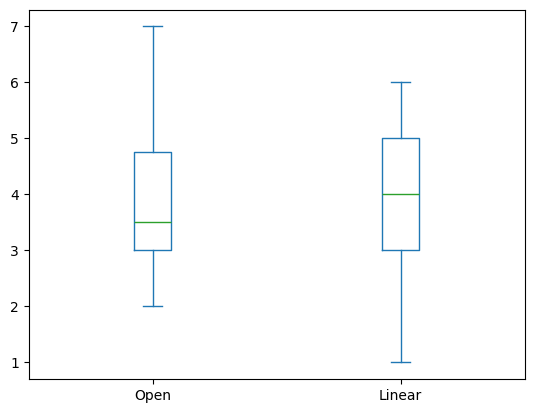

In [137]:
comparison_dfB10 = pd.DataFrame({"Open": open_dfB10,"Linear": linear_dfB10})

comparison_dfB10.plot.box()

In [138]:

open_mean = np.mean(open_dfB10)
open_std = np.std(open_dfB10)
open_n = len(open_dfB10)

linear_mean = np.mean(linear_dfB10)
linear_std = np.std(linear_dfB10)
linear_n = len(linear_dfB10)

# Confidence Intervals (95%)
open_ci = stats.t.interval(0.95, open_n - 1, loc=open_mean, scale=open_std / np.sqrt(open_n))
linear_ci = stats.t.interval(0.95, linear_n - 1, loc=linear_mean, scale=linear_std / np.sqrt(linear_n))

print(f"Open Mean: {open_mean}, CI: {open_ci}")
print(f"Linear Mean: {linear_mean}, CI: {linear_ci}")

Open Mean: 4.0, CI: (np.float64(2.2862787762424572), np.float64(5.713721223757543))
Linear Mean: 3.8333333333333335, CI: (np.float64(2.0755503911123245), np.float64(5.591116275554342))


In [144]:
narrative_cols = [
    "B01 I could easily follow the sequence of events in the game's story.",
    "B02 The sequence of events in the game made logical sense to me.",
    "B03 The game's objectives were clear to me throughout the gameplay."
]

agency_cols = [
    "B04 I felt like my actions affected the outcome of the game.",
    "B05 I understood the motivation/meaning behind the main contacts messages."
]

resolution_cols = [
    "B06 I  had no  unanswered questions about the story after completing the game",
    "B07 I felt that the story reached a complete ending.",
    "B08 All major plot points were resolved by the end of the game.",
    "B09 I was left with a clear understanding of the story's outcome.",
    "B10 The ending of the game felt appropriate for the story told."
]